Train: (60000, 28, 28)  Test: (10000, 28, 28)
X_train_f: (60000, 784)  y_train_ohe: (60000, 10)


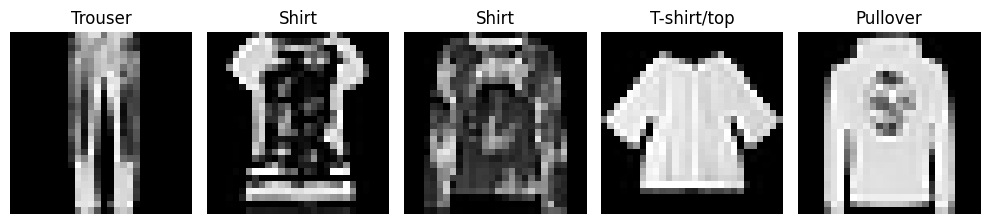

Model: "Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Baseline — Test Accuracy: 88.76%


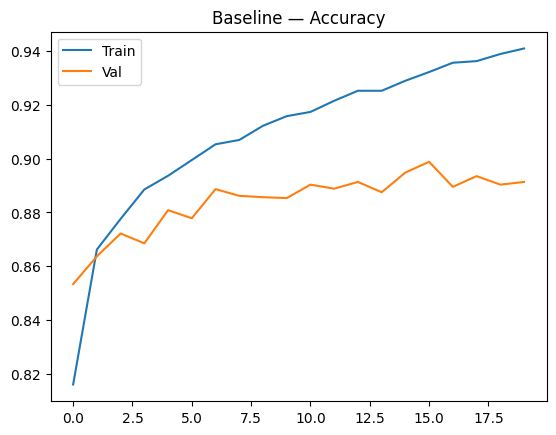

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# Normalize + Flatten
X_train_f = X_train.astype('float32').reshape(-1, 784) / 255.0
X_test_f  = X_test.astype('float32').reshape(-1, 784)  / 255.0
#print(X_train[0])
# One-hot encode
y_train_ohe = to_categorical(y_train, 10)
y_test_ohe  = to_categorical(y_test,  10)

print(f"X_train_f: {X_train_f.shape}  y_train_ohe: {y_train_ohe.shape}")

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Select 5 random indices
random_idx = np.random.choice(len(X_train), 5)

# Plot images
plt.figure(figsize=(10, 4))

for i, idx in enumerate(random_idx):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

def build_baseline():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Baseline')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_base = build_baseline()
model_base.summary()

history_base = model_base.fit(
    X_train_f, y_train_ohe,
    epochs=20, batch_size=128, validation_split=0.1, verbose=0
)

loss_base, acc_base = model_base.evaluate(X_test_f, y_test_ohe, verbose=0)
print(f"Baseline — Test Accuracy: {acc_base*100:.2f}%")

# Quick accuracy plot
plt.plot(history_base.history['accuracy'],     label='Train')
plt.plot(history_base.history['val_accuracy'], label='Val')
plt.title('Baseline — Accuracy');
plt.legend();
plt.show()

Train: 97.20%  Val: 89.22%  Gap: 7.98%


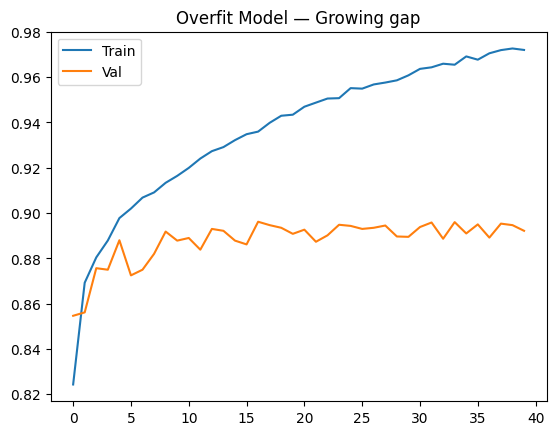

In [2]:
def build_overfit_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ], name='Overfit_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_overfit = build_overfit_model()

history_overfit = model_overfit.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_of = model_overfit.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_of  = history_overfit.history['accuracy'][-1]
val_of = history_overfit.history['val_accuracy'][-1]
print(f"Train: {tr_of*100:.2f}%  Val: {val_of*100:.2f}%  Gap: {(tr_of-val_of)*100:.2f}%")

plt.plot(history_overfit.history['accuracy'],     label='Train')
plt.plot(history_overfit.history['val_accuracy'], label='Val')
plt.title('Overfit Model — Growing gap'); plt.legend(); plt.show()

Train: 92.22%  Val: 89.13%  Gap: 3.09%


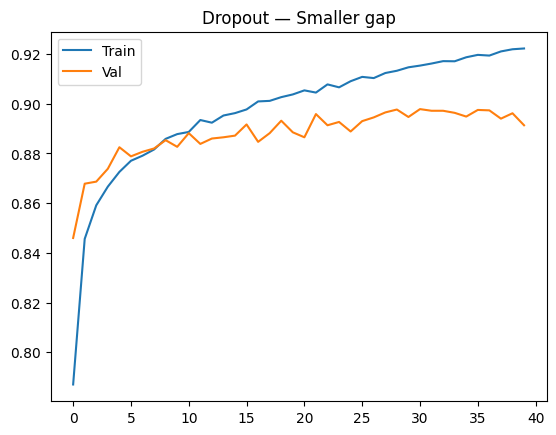

In [3]:
def build_dropout_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10,  activation='softmax')
    ], name='Dropout_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_dropout = build_dropout_model()

history_dropout = model_dropout.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_drop = model_dropout.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_d  = history_dropout.history['accuracy'][-1]
val_d = history_dropout.history['val_accuracy'][-1]
print(f"Train: {tr_d*100:.2f}%  Val: {val_d*100:.2f}%  Gap: {(tr_d-val_d)*100:.2f}%")

plt.plot(history_dropout.history['accuracy'],     label='Train')
plt.plot(history_dropout.history['val_accuracy'], label='Val')
plt.title('Dropout — Smaller gap'); plt.legend(); plt.show()

Train: 90.17%  Val: 87.20%  Gap: 2.97%


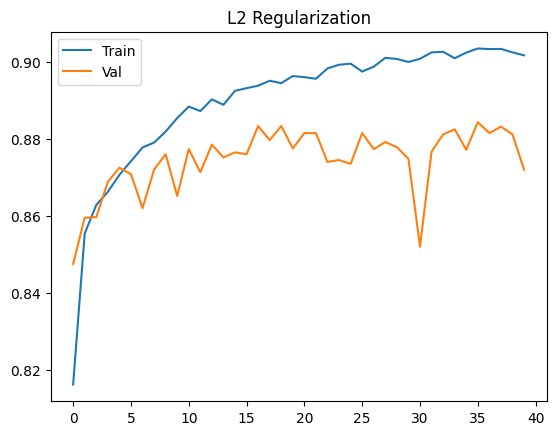

In [4]:
def build_l2_model(lam=0.001):
    reg = regularizers.l2(lam)
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(10,  activation='softmax')
    ], name='L2_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_l2 = build_l2_model(lam=0.001)

history_l2 = model_l2.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_l2 = model_l2.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_l2  = history_l2.history['accuracy'][-1]
val_l2 = history_l2.history['val_accuracy'][-1]
print(f"Train: {tr_l2*100:.2f}%  Val: {val_l2*100:.2f}%  Gap: {(tr_l2-val_l2)*100:.2f}%")

plt.plot(history_l2.history['accuracy'],     label='Train')
plt.plot(history_l2.history['val_accuracy'], label='Val')
plt.title('L2 Regularization'); plt.legend(); plt.show()

Train: 90.56%  Val: 88.02%  Gap: 2.54%


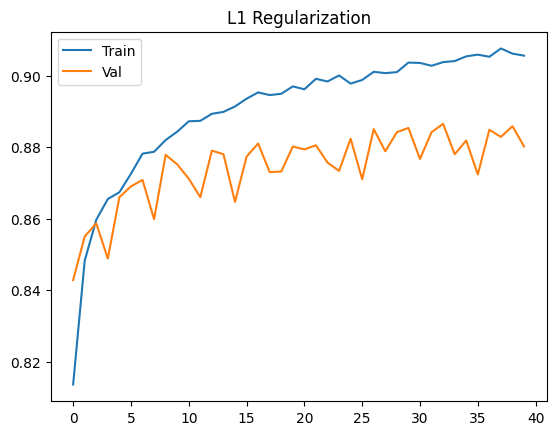

In [5]:
def build_l1_model(lam=0.0001):
    reg = regularizers.l1(lam)
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        layers.Dense(10,  activation='softmax')
    ], name='L1_Model')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_l1 = build_l1_model(lam=0.0001)

history_l1 = model_l1.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_l1 = model_l1.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_l1  = history_l1.history['accuracy'][-1]
val_l1 = history_l1.history['val_accuracy'][-1]
print(f"Train: {tr_l1*100:.2f}%  Val: {val_l1*100:.2f}%  Gap: {(tr_l1-val_l1)*100:.2f}%")

plt.plot(history_l1.history['accuracy'],     label='Train')
plt.plot(history_l1.history['val_accuracy'], label='Val')
plt.title('L1 Regularization'); plt.legend(); plt.show()

Train: 90.41%  Val: 87.98%  Gap: 2.43%


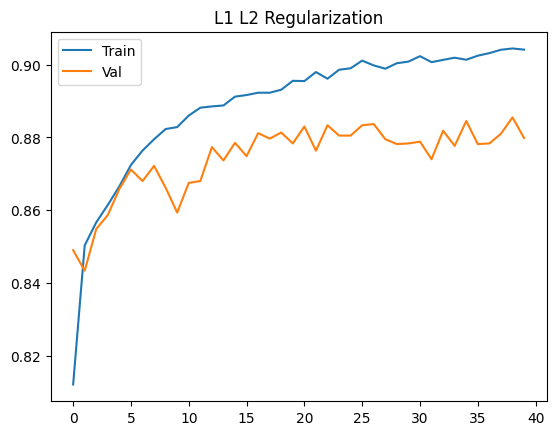

In [9]:
def build_l1_l2_model(l1=0.0001, l2=0.0001):
    reg = regularizers.l1_l2(l1=l1, l2=l2)   # ✅ Combined regularization

    model_l1l2 = keras.Sequential([
        layers.Input(shape=(784,)),
        
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(512, activation='relu', kernel_regularizer=reg),
        layers.Dense(256, activation='relu', kernel_regularizer=reg),
        
        layers.Dense(10, activation='softmax')
    ], name='L1_L2_Model')

    model_l1l2.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model_l1l2

model_l1l2 = build_l1_l2_model(l1=0.0001, l2=0.0001)

history_l1l2 = model_l1l2.fit(
    X_train_f, y_train_ohe,
    epochs=40, batch_size=128, validation_split=0.1, verbose=0
)

_, acc_l1l2 = model_l1l2.evaluate(X_test_f, y_test_ohe, verbose=0)
tr_l1  = history_l1l2.history['accuracy'][-1]
val_l1 = history_l1l2.history['val_accuracy'][-1]
print(f"Train: {tr_l1*100:.2f}%  Val: {val_l1*100:.2f}%  Gap: {(tr_l1-val_l1)*100:.2f}%")

plt.plot(history_l1l2.history['accuracy'],     label='Train')
plt.plot(history_l1l2.history['val_accuracy'], label='Val')
plt.title('L1 L2 Regularization');
plt.legend();
plt.show()

In [10]:
results = {
    'Baseline' : (acc_base,  history_base),
    'Overfit'  : (acc_of,    history_overfit),
    'Dropout'  : (acc_drop,  history_dropout),
    'L2'       : (acc_l2,    history_l2),
    'L1'       : (acc_l1,    history_l1),
    'L1 + L2'  : (acc_l1l2,  history_l1l2),
}

print(f"{'Model':<12} {'Test Acc':>10} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("-" * 54)
for name, (test_acc, hist) in results.items():
    tr  = hist.history['accuracy'][-1]
    val = hist.history['val_accuracy'][-1]
    gap = (tr - val) * 100
    print(f"{name:<12} {test_acc*100:>9.2f}% {tr*100:>9.2f}% {val*100:>9.2f}% {gap:>7.2f}%")

Model          Test Acc  Train Acc    Val Acc      Gap
------------------------------------------------------
Baseline         88.76%     94.10%     89.13%    4.96%
Overfit          88.95%     97.20%     89.22%    7.98%
Dropout          89.37%     92.22%     89.13%    3.09%
L2               86.46%     90.17%     87.20%    2.97%
L1               87.73%     90.56%     88.02%    2.54%
L1 + L2          87.34%     90.41%     87.98%    2.43%
